#Graph Neural Networks

This model is designed work with graph-structured data each restaurant is represented by a node and edges represent resturant similarity such as distances, cusine, and ratings. Nodes and edges are constructed using k-nearest neighbor similarity in feature space, allowing the GNN to learn patterns based on relationships between similar businesses.

### 1. Load dataset

In [1]:
!pip install torch-geometric scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import BallTree

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


In [30]:
path3 = "/content/drive/MyDrive/Data Mining/Project/model_dataset.csv"
df = pd.read_csv(path3)

print(df.shape)
print(df.head())


(20000, 40)
                      name          city state postal_code   latitude  \
0              Double Knot  Philadelphia    PA       19107  39.949699   
1    Hên Vietnamese Eatery   Cherry Hill    NJ       08003  39.896071   
2  Gourmet Seafood & Grill      Skippack    PA       19473  40.227668   
3           Clear Sky Cafe    Clearwater    FL       33767  27.981960   
4         Coffee House Too  Philadelphia    PA       19125  39.976728   

   longitude  business_stars  RestaurantsPriceRange2  NoiseLevel  \
0 -75.162185             4.5                     3.0         2.0   
1 -74.949167             4.5                     2.0         2.0   
2 -75.404260             3.5                     2.0         1.0   
3 -82.827297             4.5                     2.0         2.0   
4 -75.123718             4.5                     2.0         2.0   

   parking_options_count  ...  location_cluster  num_categories  \
0                    1.0  ...                11               6   
1     

### 2. Basic Checks

In [31]:
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['name', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'business_stars', 'RestaurantsPriceRange2', 'NoiseLevel', 'parking_options_count', 'meal_options_count', 'ambience_score', 'music_options_count', 'best_nights_count', 'is_full_service', 'is_bar_style', 'is_family_friendly', 'is_takeout_friendly', 'is_date_spot', 'primary_category', 'hours_open_per_week', 'days_open', 'avg_hours_per_day', 'open_late', 'open_early', 'weekend_hours', 'nearest_dist', 'num_neighbors_1km', 'same_cuisine_neighbors', 'avg_neighbor_rating', 'location_cluster', 'num_categories', 'has_nightlife', 'has_fast_food', 'has_breakfast', 'has_seafood', 'has_asian', 'has_mexican', 'has_italian', 'target']
target
0    13991
1     6009
Name: count, dtype: int64
target
0    0.69955
1    0.30045
Name: proportion, dtype: float64


### 3. Define features and target

In [33]:
X = df.drop(columns=["target"])
y = df["target"]
X = X.select_dtypes(include=[np.number]).copy()
coords = df[["latitude", "longitude"]].copy()

### 4. Handle missing values

In [34]:
# Drop highly missing columns (>70% missing)
missing_ratio = X.isnull().mean()
high_missing = missing_ratio[missing_ratio > 0.7].index

print("Dropping high-missing columns:", list(high_missing))

X = X.drop(columns=high_missing)

# Fill remaining numeric columns
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Remaining missing:", X.isnull().sum().sum())

Dropping high-missing columns: []
Remaining missing: 0


### 5. Train-Test Split

In [35]:
idx = np.arange(len(df))

train_idx, temp_idx, y_train, y_temp = train_test_split(
    idx,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [36]:
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y.iloc[temp_idx],
    test_size=0.50,
    stratify=y.iloc[temp_idx],
    random_state=42
)

### 6. Scale features

In [37]:
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled.iloc[train_idx] = scaler.fit_transform(X.iloc[train_idx])
X_scaled.iloc[val_idx] = scaler.transform(X.iloc[val_idx])
X_scaled.iloc[test_idx] = scaler.transform(X.iloc[test_idx])

x_tensor = torch.tensor(X_scaled.values, dtype=torch.float)
y_tensor = torch.tensor(y.values, dtype=torch.long)

/tmp/ipykernel_14088/1293984929.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.77695915 -1.28706895  0.77695915 ...  0.77695915 -1.28706895
 -1.28706895]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_scaled.iloc[train_idx] = scaler.fit_transform(X.iloc[train_idx])
/tmp/ipykernel_14088/1293984929.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.05131497 -0.95118973  1.05131497 ... -0.95118973 -0.95118973
  1.05131497]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_scaled.iloc[train_idx] = scaler.fit_transform(X.iloc[train_idx])
/tmp/ipykernel_14088/1293984929.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.46157474  0.68419354 -1

### 7. Build Graph

In [38]:
coords_clean = coords.fillna(coords.median(numeric_only=True))
coords_rad = np.radians(coords_clean.values)

tree = BallTree(coords_rad, metric="haversine")

radius_km = 1.0
earth_radius_km = 6371.0
radius_rad = radius_km / earth_radius_km

neighbors = tree.query_radius(coords_rad, r=radius_rad)

edge_list = []

for i, nbrs in enumerate(neighbors):
    for j in nbrs:
        if i != j:
            edge_list.append([i, j])

if len(edge_list) == 0:
    print("No radius-based edges found. Using k-nearest neighbors instead.")
    distances, indices = tree.query(coords_rad, k=6)

    for i, nbrs in enumerate(indices):
        for j in nbrs[1:]:
            edge_list.append([i, j])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print("Number of edges:", edge_index.shape[1])

Number of edges: 3135892


### 8. PyTorch Geometric

In [39]:
data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor
)

train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

### 9. GNN Model

In [40]:
class RestaurantGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.lin = torch.nn.Linear(hidden2, 2)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.lin(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RestaurantGCN(data.num_features).to(device)
data = data.to(device)

In [41]:
classes = np.unique(y.iloc[train_idx])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y.iloc[train_idx]
)

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

### 10. Train and Evaluate Model

In [42]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

train_losses = []
val_aucs = []

best_val_auc = 0
best_state = None
patience = 25
patience_counter = 0

for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    logits = model(data)

    loss = F.cross_entropy(
        logits[data.train_mask],
        data.y[data.train_mask],
        weight=weights
    )

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = F.softmax(logits, dim=1)[:, 1]

        val_probs = probs[data.val_mask].detach().cpu().numpy()
        val_true = data.y[data.val_mask].detach().cpu().numpy()

        val_auc = roc_auc_score(val_true, val_probs)
        val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model
model.load_state_dict(best_state)

Epoch 000 | Loss: 0.7182 | Val AUC: 0.6081
Epoch 020 | Loss: 0.5517 | Val AUC: 0.7943
Epoch 040 | Loss: 0.5380 | Val AUC: 0.8005
Epoch 060 | Loss: 0.5261 | Val AUC: 0.8031
Epoch 080 | Loss: 0.5193 | Val AUC: 0.8042
Epoch 100 | Loss: 0.5115 | Val AUC: 0.8056
Epoch 120 | Loss: 0.5024 | Val AUC: 0.8067
Epoch 140 | Loss: 0.4968 | Val AUC: 0.8069
Epoch 160 | Loss: 0.4931 | Val AUC: 0.8064
Epoch 180 | Loss: 0.4872 | Val AUC: 0.8089
Epoch 200 | Loss: 0.4848 | Val AUC: 0.8111
Epoch 220 | Loss: 0.4844 | Val AUC: 0.8079
Epoch 240 | Loss: 0.4808 | Val AUC: 0.8095
Epoch 260 | Loss: 0.4790 | Val AUC: 0.8126
Epoch 280 | Loss: 0.4785 | Val AUC: 0.8092


<All keys matched successfully>

In [43]:
model.eval()

with torch.no_grad():
    logits = model(data)
    probs = F.softmax(logits, dim=1)[:, 1]

    test_probs = probs[data.test_mask].detach().cpu().numpy()
    test_true = data.y[data.test_mask].detach().cpu().numpy()

    test_preds = (test_probs > 0.5).astype(int)

test_auc = roc_auc_score(test_true, test_probs)
test_acc = accuracy_score(test_true, test_preds)

print("Final Test AUC:", test_auc)
print("Final Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(test_true, test_preds, target_names=["Closed", "Open"]))

Final Test AUC: 0.8116155412518724
Final Test Accuracy: 0.7023333333333334

Classification Report:
              precision    recall  f1-score   support

      Closed       0.90      0.65      0.75      2099
        Open       0.50      0.82      0.62       901

    accuracy                           0.70      3000
   macro avg       0.70      0.74      0.69      3000
weighted avg       0.78      0.70      0.71      3000



### 11. Top Features

Confusion matrix

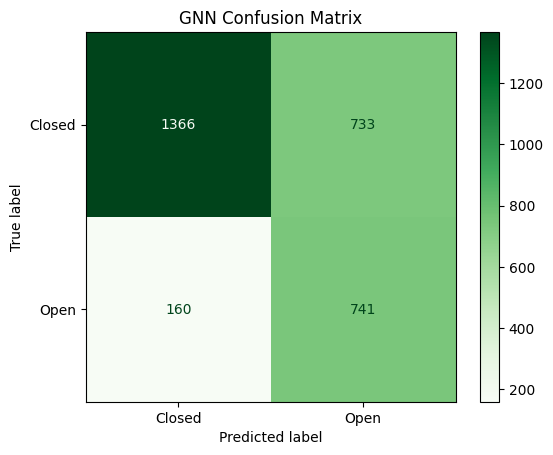

In [44]:
cm = confusion_matrix(test_true, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Closed", "Open"]
)

disp.plot(cmap="Greens", values_format="d")
plt.title("GNN Confusion Matrix")
plt.grid(False)
plt.show()

ROC curve

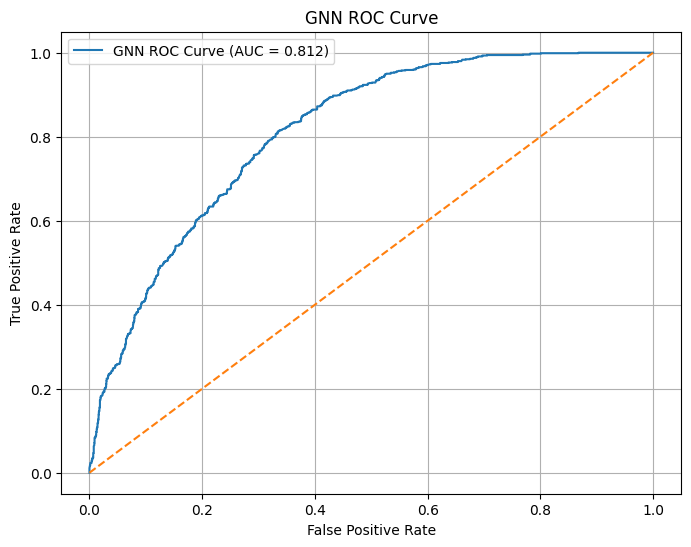

In [45]:
fpr, tpr, thresholds = roc_curve(test_true, test_probs)
roc_auc = roc_auc_score(test_true, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"GNN ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Training curve

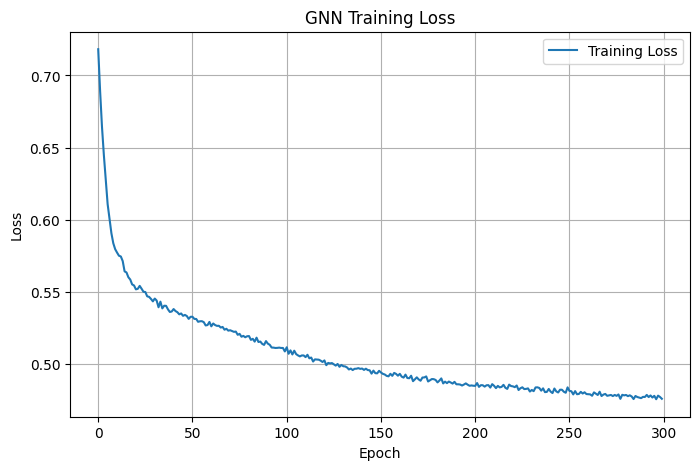

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

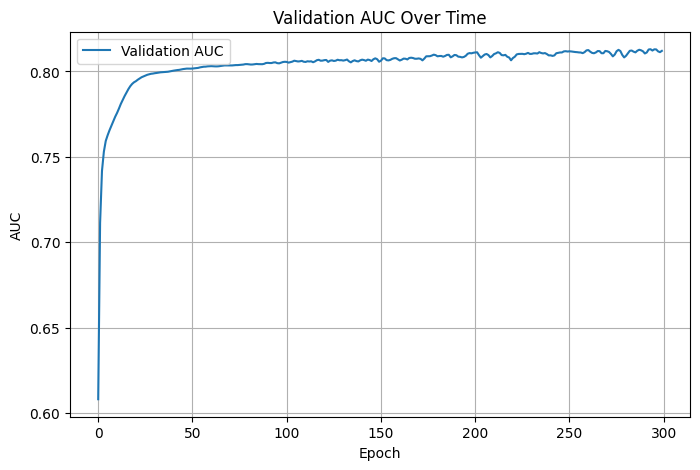

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(val_aucs, label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC Over Time")
plt.legend()
plt.grid(True)
plt.show()

Get graph embeddings and t-SNE visualization

Embeddings shape: (20000, 32) Labels shape: (20000,)


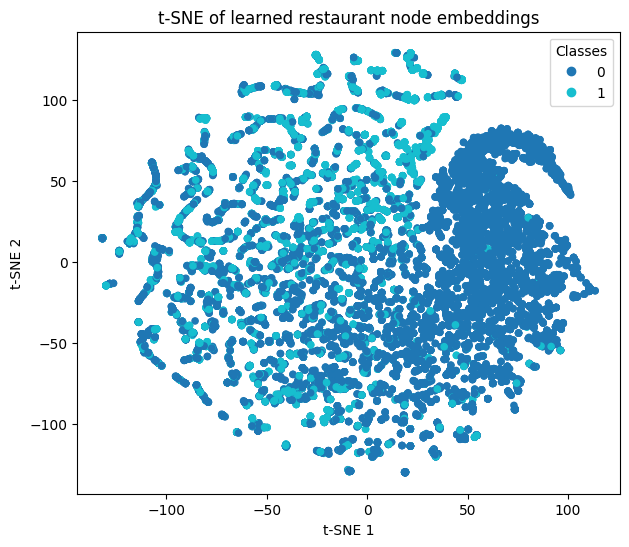

In [48]:
@torch.no_grad()
def get_node_embeddings_and_labels():
    model.eval()

    x, edge_index = data.x, data.edge_index

    x = model.conv1(x, edge_index)
    x = F.relu(x)

    x = model.conv2(x, edge_index)
    x = F.relu(x)

    embs = x.cpu().numpy()
    labels = data.y.cpu().numpy()

    return embs, labels

embs, labels = get_node_embeddings_and_labels()
print("Embeddings shape:", embs.shape, "Labels shape:", labels.shape)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb2 = tsne.fit_transform(embs)

# plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb2[:, 0], emb2[:, 1], c=labels, cmap='tab10', s=20)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE of learned restaurant node embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

# Save

In [49]:
torch.save(model.state_dict(), "gnn_model.pt")


import joblib
joblib.dump(scaler, "gnn_scaler.pkl")

import json
with open("gnn_feature_columns.json", "w") as f:
    json.dump(list(X.columns), f)

emb_df = pd.DataFrame(embs, columns=[f"gnn_emb_{i}" for i in range(embs.shape[1])])
emb_df.to_csv("gnn_embeddings.csv", index=False)